# Heatmap

A heatmap colors every cell of a table by its value, so a grid of numbers over two categorical dimensions reads at a glance: where the hot cells are, and what pattern they form. This guide shows how to create heatmaps with the [datachart.charts.Heatmap](../../../references/charts/#datachart.charts.Heatmap) function, starting with the basics and building up to worked examples on real data.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-heatmap), which maps common tasks to the parameter or style attribute that does the job.

In [1]:
from datachart.charts import Heatmap

## Basics

The examples in this guide share one dataset: the monthly climate of six cities on four continents, Reykjavik, Moscow, Ljubljana, Cairo, Singapore and Sydney. `temperatures` holds the mean air temperature of every month in °C, and `precipitation` the mean monthly rainfall in mm. The values are approximate, rounded from the published 1991 to 2020 climate normals of each city's main weather station, and live in a hidden cell. The table has several stories in it, and the customizations below bring them out: a freezing Moscow winter, a Singapore that never changes, a Sydney whose seasons run backwards, and a Cairo where it almost never rains.

In [2]:
CITIES = ["Reykjavik", "Moscow", "Ljubljana", "Cairo", "Singapore", "Sydney"]
MONTHS = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# approximate mean monthly temperature in °C (1991-2020 normals), one row per city
TEMPERATURES = [
    [-0.2, 0.4, 0.9, 3.2, 6.6, 9.5, 11.3, 10.9, 8.3, 4.9, 1.9, 0.3],
    [-6.5, -6.7, -1.0, 6.7, 13.2, 17.0, 19.2, 17.0, 11.3, 5.6, -1.2, -5.2],
    [0.8, 2.4, 6.8, 11.5, 16.2, 20.1, 22.0, 21.4, 16.6, 11.5, 5.9, 1.3],
    [14.0, 15.2, 17.9, 21.9, 25.3, 27.8, 28.5, 28.5, 26.8, 24.0, 19.6, 15.5],
    [26.5, 27.1, 27.5, 28.0, 28.3, 28.3, 27.9, 27.9, 27.6, 27.6, 27.0, 26.4],
    [23.0, 22.9, 21.5, 18.8, 15.8, 13.3, 12.5, 13.5, 16.0, 18.2, 20.0, 21.9],
]

# approximate mean monthly precipitation in mm (1991-2020 normals), one row per city
PRECIPITATION = [
    [90, 80, 80, 60, 55, 45, 50, 60, 70, 85, 80, 95],
    [50, 40, 35, 40, 50, 80, 85, 80, 65, 70, 55, 50],
    [75, 70, 85, 95, 105, 120, 110, 125, 135, 145, 130, 105],
    [5, 4, 4, 1, 1, 0, 0, 0, 0, 1, 3, 6],
    [240, 160, 185, 180, 170, 130, 150, 175, 170, 190, 260, 290],
    [100, 120, 130, 125, 120, 130, 95, 80, 70, 75, 85, 80],
]

temperatures = {"x": MONTHS, "y": CITIES, "z": TEMPERATURES}
precipitation = {"x": MONTHS, "y": CITIES, "z": PRECIPITATION}

The data is a dictionary: `z` is a 2D list, one inner list per row and one value per cell, while `x` names the columns and `y` the rows. The first row is drawn at the top and the first column at the left:

In [3]:
{key: value[:2] for key, value in temperatures.items()}

{'x': ['Jan', 'Feb'],
 'y': ['Reykjavik', 'Moscow'],
 'z': [[-0.2, 0.4, 0.9, 3.2, 6.6, 9.5, 11.3, 10.9, 8.3, 4.9, 1.9, 0.3],
  [-6.5, -6.7, -1.0, 6.7, 13.2, 17.0, 19.2, 17.0, 11.3, 5.6, -1.2, -5.2]]}

**Basic example.** Only the `data` argument is required. Every cell is colored by its value, the lowest value in the table getting the first color of the colormap and the highest the last, and the `x` and `y` labels name the columns and rows. The pattern is visible straight away: the Cairo and Singapore rows at the warm end all year, Moscow's winter corner at the cold end, and a Sydney row that is warmest where the others are coldest.

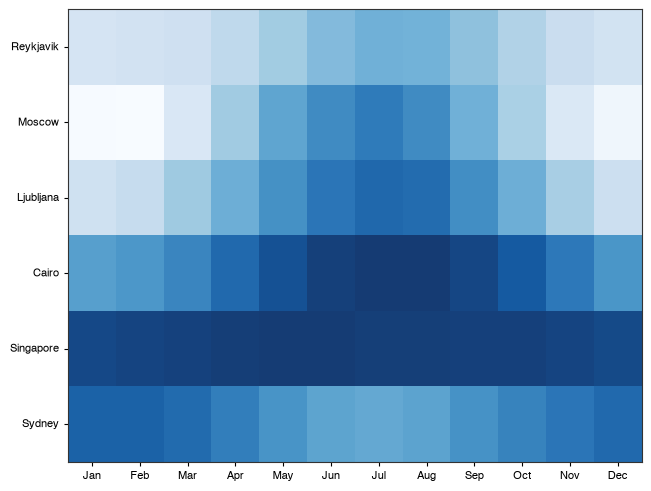

In [4]:
Heatmap(
    # add the data to the chart
    data=temperatures
).show()

## Customizing the Heatmap

Every customization is either a keyword argument of `Heatmap` or a `plot_heatmap_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                     | See |
| :------------------------------------------ | :---------------------------------------------------------------------- | :-- |
| add a title and axis labels                 | `title`, `xlabel`, `ylabel`                                             | [Title and axis labels](#title-and-axis-labels) |
| tick only some rows or columns              | `xticks`, `xticklabels`, `yticks`, `yticklabels`                        | [Ticks and labels](#ticks-and-labels) |
| rotate the tick labels                      | `xtickrotate`, `ytickrotate`                                            | [Ticks and labels](#ticks-and-labels) |
| resize the figure or keep the cells square  | `figsize`, `aspect_ratio`                                               | [Figure size and aspect ratio](#figure-size-and-aspect-ratio) |
| show the colorbar                           | `show_colorbars`                                                        | [Colorbar and cell values](#colorbar-and-cell-values) |
| write the values into the cells             | `show_heatmap_values`, `valfmt`                                         | [Colorbar and cell values](#colorbar-and-cell-values) |
| caption, move, or format the colorbar       | `colorbar={"label": ..., "location": ..., "format": ..., "ticks": ...}` | [Colorbar placement](#colorbar-placement) |
| change the colormap or transparency         | `style={"plot_heatmap_cmap": ..., "plot_heatmap_alpha": ...}`           | [Heatmap style](#heatmap-style) |
| style the cell values                       | `style={"plot_heatmap_font_size": ..., "plot_heatmap_font_color": ..., ...}` | [Heatmap style](#heatmap-style) |
| draw borders between the cells              | `style={"plot_heatmap_edge_width": ..., "plot_heatmap_edge_color": ...}` | [Heatmap style](#heatmap-style) |
| center a diverging colormap on a value      | `vmin`, `vmax`                                                          | [Normalization](#normalization) |
| spread skewed values over the colormap      | `norm`                                                                  | [Normalization](#normalization) |
| highlight some cells, mute the rest         | `emphasis_rule`, an `emphasis` grid in `data`                           | [Emphasis](#emphasis) |
| put a note on a cell                        | `texts`                                                                 | [Text annotations](#text-annotations) |
| compare several tables side by side         | `data` as a list of dicts, `subtitle`                                   | [Multiple Heatmaps](#multiple-heatmaps) |
| arrange the subplots                        | `max_cols`, `sharex`, `sharey`                                          | [Subplot layout and shared axes](#subplot-layout-and-shared-axes) |
| leave cells without data empty              | `None` in `z`                                                           | [Blank cells](#blank-cells) |
| show only part of the table                 | `xmin`, `xmax`, `ymin`, `ymax`                                          | [Axis range](#axis-range) |
| use dates as row or column labels           | `date` objects as `x` or `y`, `xticks_format`, `yticks_format`          | [Date labels](#date-labels) |
| save the chart to a file                    | `save_figure`                                                           | [Saving Figures](../../utility/saving/) guide |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `legend={"location": ..., "alignment": ...}` | [`LEGEND_LOCATION`](../../../references/constants/#datachart.constants.LEGEND_LOCATION), [`LEGEND_ALIGN`](../../../references/constants/#datachart.constants.LEGEND_ALIGN) |
| `show_grid` | [`SHOW_GRID`](../../../references/constants/#datachart.constants.SHOW_GRID) |
| `aspect_ratio` | [`ASPECT_RATIO`](../../../references/constants/#datachart.constants.ASPECT_RATIO) |
| `norm` | [`NORMALIZE`](../../../references/constants/#datachart.constants.NORMALIZE) |
| `valfmt` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT) |
| `xticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |
| `yticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |
| `colorbar={"location": ..., "format": ..., "orientation": ...}` | [`COLORBAR_LOCATION`](../../../references/constants/#datachart.constants.COLORBAR_LOCATION), [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`ORIENTATION`](../../../references/constants/#datachart.constants.ORIENTATION) |

The full list of style attributes is in the [datachart.typings.HeatmapStyleAttrs](../../../references/typings/#datachart.typings.HeatmapStyleAttrs) type; the full list of parameters is in the [datachart.charts.Heatmap](../../../references/charts/#datachart.charts.Heatmap) reference.

### Title and axis labels

A heatmap has three quantities, the two axes and the color, and the reader needs all three named. `title` says what the colors measure, with its unit, and `xlabel` and `ylabel` name the dimensions of the table.

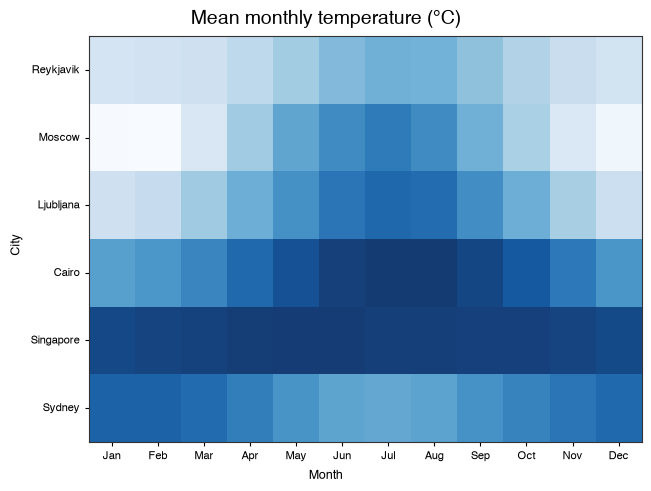

In [5]:
Heatmap(
    data=temperatures,
    # say what the colors measure
    title="Mean monthly temperature (°C)",
    # name the columns and the rows
    xlabel="Month",
    ylabel="City",
).show()

### Ticks and labels

Twelve month names are more labels than a small figure has room for, and a table with a hundred columns can never label them all. Column *j* sits at `x = j` and row *i* at `y = i`, counting from zero, so `xticks` and `yticks` take the indices to tick and `xticklabels` and `yticklabels` their labels; an explicit pair replaces the `x` or `y` labels of the data. Here only the first month of each season is ticked. `xtickrotate` and `ytickrotate` tilt the tick labels, whichever labels are shown, which keeps long names from crowding.

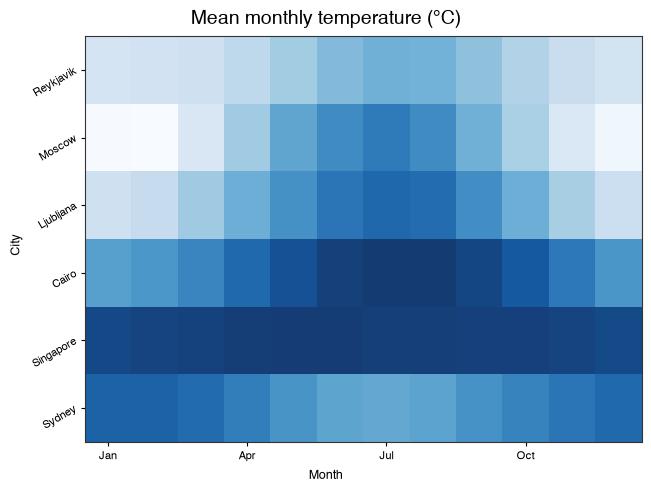

In [6]:
Heatmap(
    data=temperatures,
    title="Mean monthly temperature (°C)",
    xlabel="Month",
    ylabel="City",
    # tick the first month of each season
    xticks=[0, 3, 6, 9],
    xticklabels=["Jan", "Apr", "Jul", "Oct"],
    # tilt the city names
    ytickrotate=30,
).show()

### Figure size and aspect ratio

A table of six rows and twelve columns is twice as wide as it is tall, and the default figure is nearly square, so the cells come out tall and narrow. `figsize` takes a `(width, height)` tuple in inches or a preset from [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE). The cells stretch to fill the axes by default ([ASPECT_RATIO.AUTO](../../../references/constants/#datachart.constants.ASPECT_RATIO)); `ASPECT_RATIO.EQUAL` keeps them square and shrinks the axes to fit, which suits a matrix whose rows and columns are the same kind of thing, like a correlation matrix, and a wide, short figure like this one.

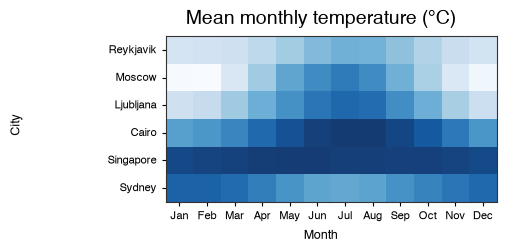

In [7]:
from datachart.constants import FIG_SIZE, ASPECT_RATIO

Heatmap(
    data=temperatures,
    title="Mean monthly temperature (°C)",
    xlabel="Month",
    ylabel="City",
    # a page-wide figure
    figsize=FIG_SIZE.FULL_SHORT,
    # square cells
    aspect_ratio=ASPECT_RATIO.EQUAL,
).show()

### Colorbar and cell values

Colors show which cells are warmer, not by how much. `show_colorbars` adds the scale that maps colors back to values, and `show_heatmap_values` writes each value into its cell; a value on a dark cell is written in white, so it stays legible across the colormap. `valfmt` formats the cell values: a [VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) member or a format string that names the value `x`, such as `"{x:.1f}"` (a string without `x`, such as `"{z:.1f}"`, is not valid). The temperatures carry one decimal, so `VALUE_FORMAT.DECIMAL` keeps it. With the values written in, the chart answers both questions: the pattern from the colors, the exact numbers from the cells.

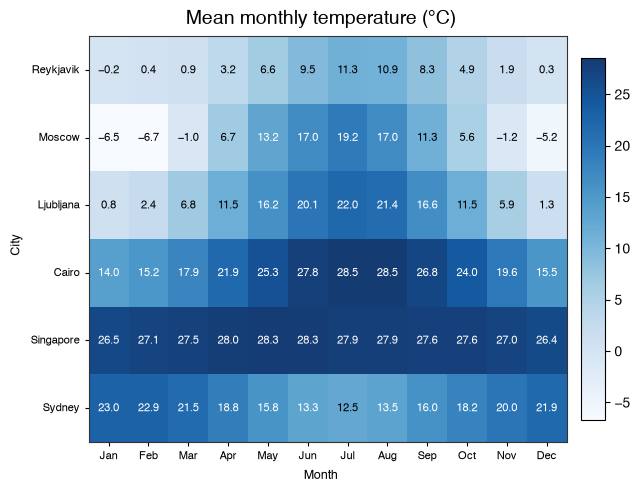

In [8]:
from datachart.constants import VALUE_FORMAT

Heatmap(
    data=temperatures,
    title="Mean monthly temperature (°C)",
    xlabel="Month",
    ylabel="City",
    figsize=FIG_SIZE.FULL_MEDIUM,
    # add the color scale
    show_colorbars=True,
    # write the values into the cells, with one decimal
    show_heatmap_values=True,
    valfmt=VALUE_FORMAT.DECIMAL,
).show()

### Colorbar placement

A colorbar on the right takes width from the table, and a wide table needs every bit of it. `colorbar` takes a dictionary ([ColorbarSettingAttrs](../../../references/typings/#datachart.typings.ColorbarSettingAttrs)): `location` puts the bar on any edge with a [COLORBAR_LOCATION](../../../references/constants/#datachart.constants.COLORBAR_LOCATION) member, `label` captions it, `format` formats its tick labels (a `VALUE_FORMAT` member or a string naming the value `x`), and `ticks` picks the tick positions. `orientation`, an [ORIENTATION](../../../references/constants/#datachart.constants.ORIENTATION) member, is the older control: with no `location`, a vertical bar sits on the right and a horizontal one on top; when both are given, `location` wins. Under the table, captioned and ticked every 5 °C, the bar reads like a legend; the month names need no axis label, which would otherwise print below the bar.

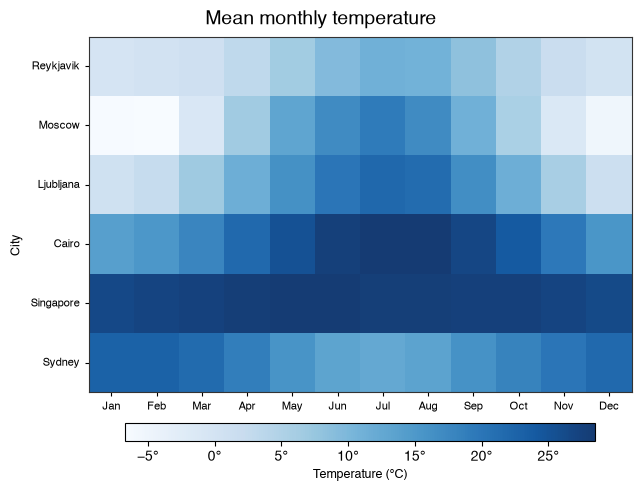

In [9]:
from datachart.constants import COLORBAR_LOCATION

Heatmap(
    data=temperatures,
    title="Mean monthly temperature",
    ylabel="City",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_colorbars=True,
    # a captioned colorbar under the table, ticked every 5 degrees
    colorbar={
        "location": COLORBAR_LOCATION.BOTTOM,
        "label": "Temperature (°C)",
        "format": "{x:.0f}°",
        "ticks": [-5, 0, 5, 10, 15, 20, 25],
    },
).show()

### Heatmap style

The colormap is the style choice that matters most, because it decides what the reader sees as "a lot". A sequential colormap such as `COLORS.YlOrRd` or `COLORS.Blues` runs from light to dark and suits a magnitude, where more is simply more. A diverging colormap such as `COLORS.Coolwarm` or `COLORS.RdBu` runs through a neutral middle and suits signed values around a meaningful midpoint ([Normalization](#normalization) shows how to place that midpoint). `plot_heatmap_cmap` takes a [COLORS](../../../references/constants/#datachart.constants.COLORS) member or a list of hex colors, and the [Colormaps](../../styling/colormaps/) guide renders them all.

The other attributes set the transparency (`plot_heatmap_alpha`), the look of the cell values (`plot_heatmap_font_size`, `plot_heatmap_font_color`, `plot_heatmap_font_style` with [FONT_STYLE](../../../references/constants/#datachart.constants.FONT_STYLE), `plot_heatmap_font_weight` with [FONT_WEIGHT](../../../references/constants/#datachart.constants.FONT_WEIGHT)), the frame around the table (`plot_heatmap_frame_color`), and the borders between the cells (`plot_heatmap_edge_width`, 0 by default, and `plot_heatmap_edge_color`). Thin white borders separate neighboring cells of similar shade, which the flat Singapore row needs. Any attribute left out keeps the value of the active theme. `show_grid` ([SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID)) draws the axis grid, which runs through the cell centers, so borders are the better way to separate cells.

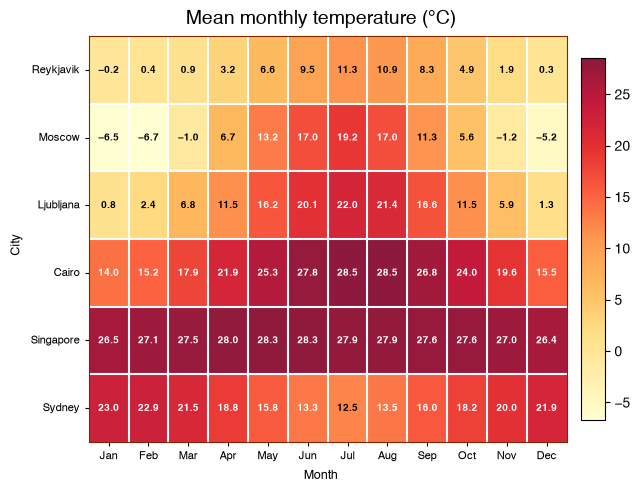

In [10]:
from datachart.constants import COLORS, FONT_WEIGHT

Heatmap(
    data=temperatures,
    style={
        # a sequential colormap: warmer is darker
        "plot_heatmap_cmap": COLORS.YlOrRd,
        "plot_heatmap_alpha": 0.9,
        # small bold cell values
        "plot_heatmap_font_size": 7,
        "plot_heatmap_font_weight": FONT_WEIGHT.BOLD,
        # white borders between the cells, a dark red frame around them
        "plot_heatmap_edge_width": 1.5,
        "plot_heatmap_edge_color": "#FFFFFF",
        "plot_heatmap_frame_color": "#7f2704",
    },
    title="Mean monthly temperature (°C)",
    xlabel="Month",
    ylabel="City",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_colorbars=True,
    show_heatmap_values=True,
    valfmt=VALUE_FORMAT.DECIMAL,
).show()

### Normalization

The colors come from a two-step mapping: each value is first normalized to the 0 to 1 range, then picks its color from the colormap. Both steps can be tuned, and each tuning is a claim about the data, so it should be an honest one.

**Value range.** By default the smallest value maps to the first color and the largest to the last. `vmin` and `vmax` pin the endpoints instead. With a diverging colormap this is what places the neutral middle on a meaningful value: the temperatures run from −6.7 to 28.5 °C, so the white center of `COLORS.Coolwarm` would land on about 11 °C, a value that means nothing. A range of −30 to 30 °C centers it on freezing, and every blue cell is now a month below zero. Pinning the range is also how two heatmaps get comparable colors (see [Example 3](#example-3-did-fine-tuning-fix-the-confusion-shared-value-range-and-a-grid)).

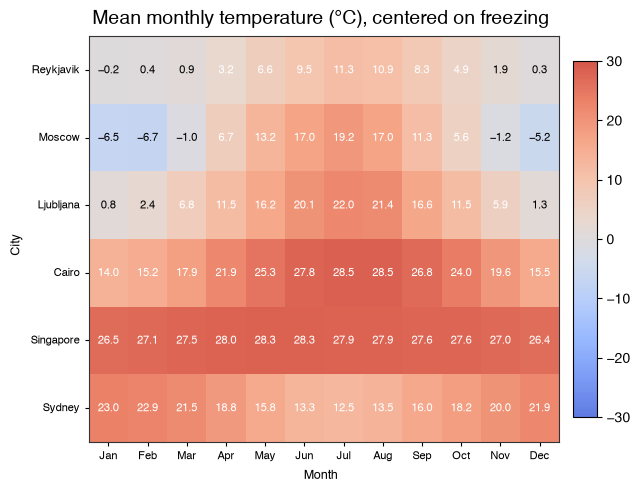

In [11]:
Heatmap(
    data=temperatures,
    # a diverging colormap, centered on 0 °C by a symmetric range
    style={"plot_heatmap_cmap": COLORS.Coolwarm},
    vmin=-30,
    vmax=30,
    title="Mean monthly temperature (°C), centered on freezing",
    xlabel="Month",
    ylabel="City",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_colorbars=True,
    show_heatmap_values=True,
    valfmt=VALUE_FORMAT.DECIMAL,
).show()

**Normalization.** `norm` changes how the values spread over the 0 to 1 range, with a [NORMALIZE](../../../references/constants/#datachart.constants.NORMALIZE) member: `LINEAR` (the default); `LOG`, for positive values spanning orders of magnitude, where zero and negative values have no logarithm and are left blank; `SYMLOG` and `ASINH`, which are linear near zero and logarithmic beyond, so they keep zeros and signed values; and `LOGIT`, for proportions strictly between 0 and 1. It rescales the colors, not an axis, unlike the `scalex` and `scaley` of the other charts.

A non-linear normalization is honest when the question is about ratios rather than differences, or when a few large values would otherwise flatten everything else, and the colorbar must stay on so the reader can see the scale is not linear. The `precipitation` table is such a case: Singapore's 290 mm December claims the dark end of a linear colormap, and every other city's wet and dry seasons fade into the same pale shades. A log normalization would blank Cairo's rainless months; `SYMLOG` keeps them and spreads the low end, so Cairo's wet winter and dry summer show, at the price of compressing the differences between the wetter cities. The colorbar makes that trade visible, which is why it stays on.

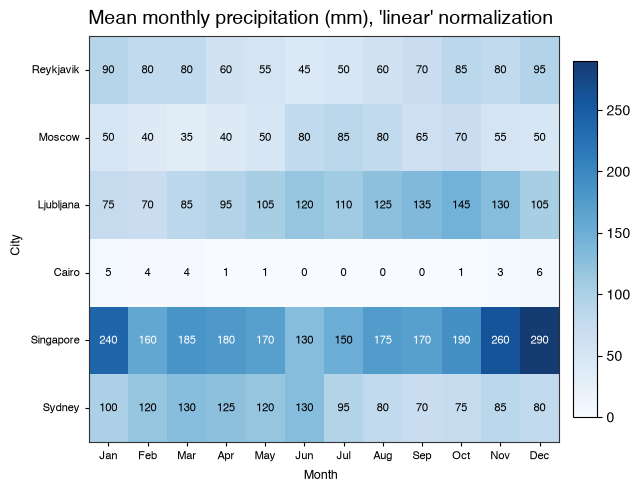

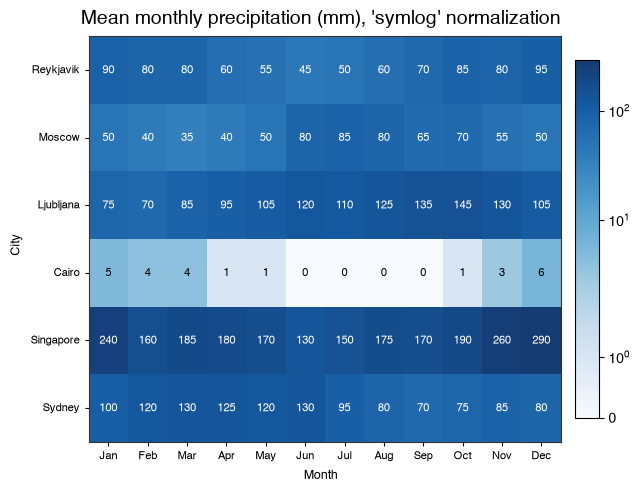

In [12]:
from datachart.constants import NORMALIZE

for norm in [NORMALIZE.LINEAR, NORMALIZE.SYMLOG]:
    Heatmap(
        data=precipitation,
        # how the values spread over the colormap
        norm=norm,
        title=f"Mean monthly precipitation (mm), '{norm}' normalization",
        xlabel="Month",
        ylabel="City",
        figsize=FIG_SIZE.FULL_MEDIUM,
        show_colorbars=True,
        show_heatmap_values=True,
        valfmt=VALUE_FORMAT.INTEGER,
    ).show()

### Emphasis

A heatmap shows every cell with the same weight, but a question is usually about a few of them. A heatmap has no series to mute, so the `emphasis` parameter of the series charts raises a `ValueError`; emphasis works per cell instead. `emphasis_rule` picks the cells from their values with a one-key rule: `{"above": v}` or `{"below": v}` (strict), `{"between": (lo, hi)}` (inclusive), `{"top": n}` or `{"bottom": n}`. The matching cells are outlined, the rest fade to the theme's muted alpha and still read on the colormap, and a blank cell never matches. Asking which months average below freezing picks out Moscow's long winter and a single Reykjavik month:

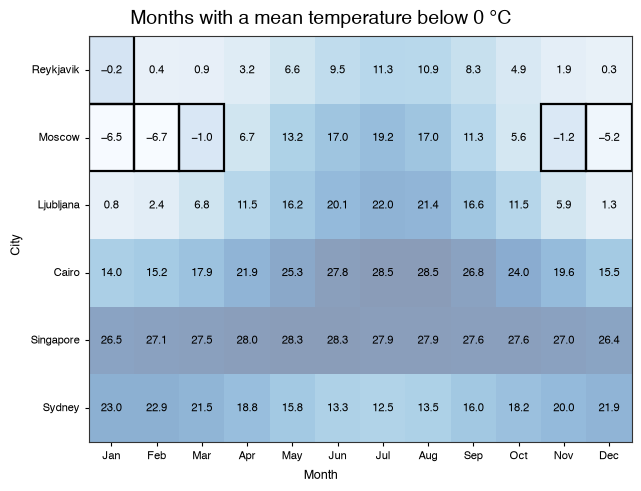

In [13]:
Heatmap(
    data=temperatures,
    # highlight the months below freezing, mute the rest
    emphasis_rule={"below": 0},
    title="Months with a mean temperature below 0 °C",
    xlabel="Month",
    ylabel="City",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_heatmap_values=True,
    valfmt=VALUE_FORMAT.DECIMAL,
).show()

When the cells to mark do not follow from one threshold, `data` takes an `emphasis` grid aligned with `z`, one role per cell: `"highlight"`, `"background"`, or `None` to leave the cell as it is ([EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS)). A role in the grid wins over the rule. Marking each city's warmest month, and muting the rest, shows Sydney's summer at the start of the year, Singapore's in May and June, and Cairo's July and August tied; the [Highlighting](../../styling/highlighting/#emphasis-picked-by-a-rule) guide covers emphasis across every chart.

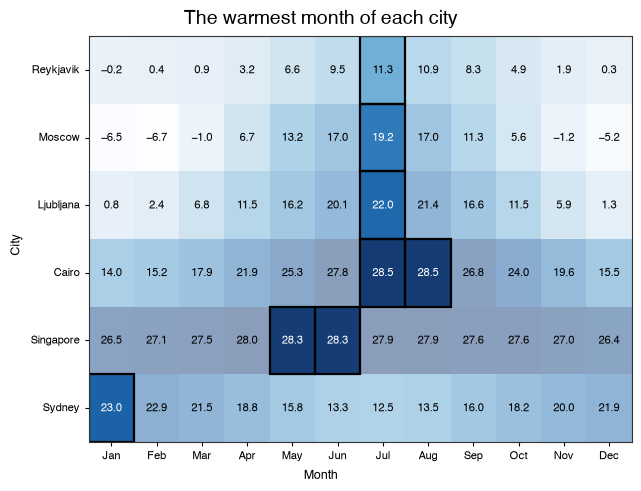

In [14]:
# each city's warmest month highlighted, every other cell muted
warmest = [
    ["highlight" if value == max(row) else "background" for value in row]
    for row in TEMPERATURES
]

Heatmap(
    data={**temperatures, "emphasis": warmest},
    title="The warmest month of each city",
    xlabel="Month",
    ylabel="City",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_heatmap_values=True,
    valfmt=VALUE_FORMAT.DECIMAL,
).show()

### Text annotations

A pattern that surprises the reader deserves a sentence. `texts` places a note on the chart; its position is in data coordinates by default, where a cell sits at (column index, row index), or in axes fractions with `"coords": "axes"`, and a `target` draws a connector to a cell. The [Text Annotations](../../utility/annotations/) guide covers placement and styling ([TextSettingAttrs](../../../references/typings/#datachart.typings.TextSettingAttrs)). The note below explains why Sydney's row runs backwards.

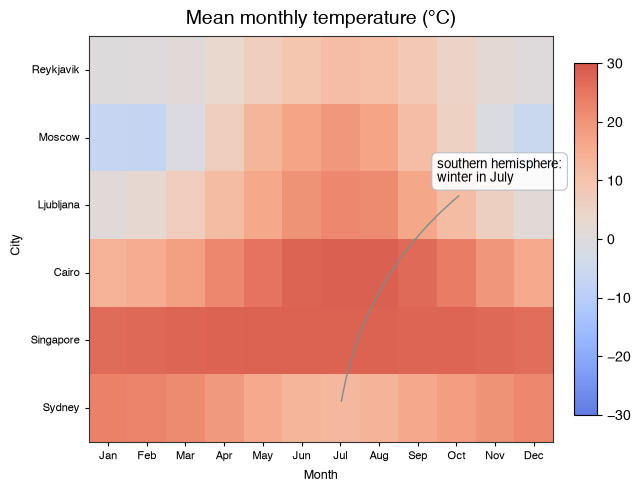

In [15]:
Heatmap(
    data=temperatures,
    style={"plot_heatmap_cmap": COLORS.Coolwarm},
    vmin=-30,
    vmax=30,
    # a note pointing at Sydney's July, the middle of its winter
    texts={
        "text": "southern hemisphere:\nwinter in July",
        "x": 8.5,
        "y": 1.5,
        "target": (6, 5),
    },
    title="Mean monthly temperature (°C)",
    xlabel="Month",
    ylabel="City",
    figsize=FIG_SIZE.FULL_MEDIUM,
    show_colorbars=True,
).show()

## Multiple Heatmaps

To compare several tables, pass a list of dictionaries to `data`. Each table gets its own subplot, since two tables cannot share one set of cells, with its `subtitle` above it, while `title`, `xlabel` and `ylabel` stay global. The per-chart parameters (`subtitle`, `style`, `valfmt`, `norm`, `vmin`, `vmax`, `colorbar`, and the tick parameters) take a list with one entry per table, or a single value for all of them; `None` in a list keeps the default for that table. Temperature and rainfall are different quantities, so each table gets its own colormap and its own normalization.

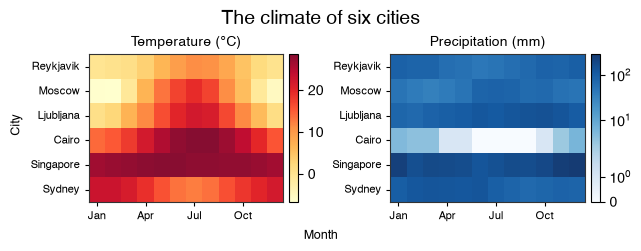

In [16]:
Heatmap(
    # one table per subplot
    data=[temperatures, precipitation],
    subtitle=["Temperature (°C)", "Precipitation (mm)"],
    # a colormap and a normalization per table
    style=[{"plot_heatmap_cmap": COLORS.YlOrRd}, {"plot_heatmap_cmap": COLORS.Blues}],
    norm=[None, NORMALIZE.SYMLOG],
    title="The climate of six cities",
    xlabel="Month",
    ylabel="City",
    xticks=[0, 3, 6, 9],
    xticklabels=["Jan", "Apr", "Jul", "Oct"],
    figsize=FIG_SIZE.FULL_SHORT,
    show_colorbars=True,
).show()

### Subplot layout and shared axes

Side by side, twelve columns each leave no room for the cell values. `max_cols` limits the subplots per row, so `max_cols=1` stacks the tables and gives each the full width. `sharex` and `sharey` share an axis across subplots and label it once, on the outer subplots; both tables have the same months, so `sharex=True` drops the repeated month labels. `valfmt` as a list keeps the decimal on the temperatures and writes the rainfall as whole numbers.

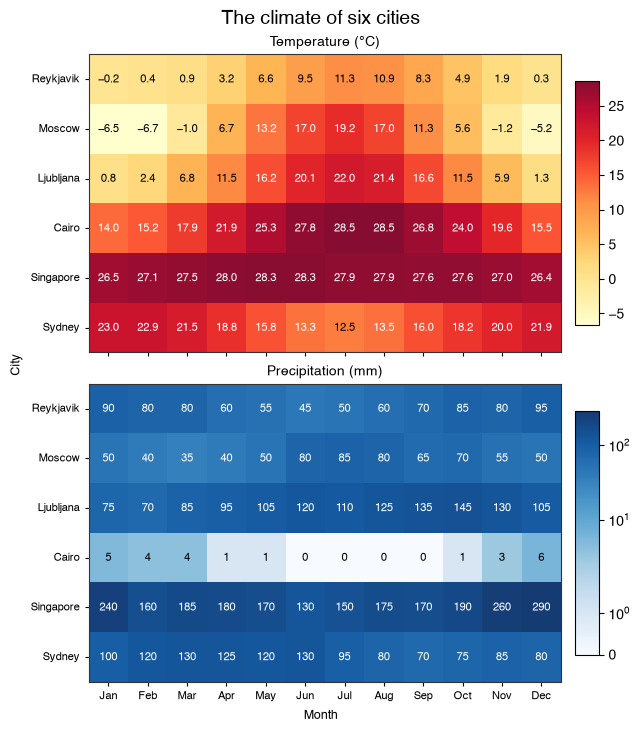

In [17]:
Heatmap(
    data=[temperatures, precipitation],
    subtitle=["Temperature (°C)", "Precipitation (mm)"],
    style=[{"plot_heatmap_cmap": COLORS.YlOrRd}, {"plot_heatmap_cmap": COLORS.Blues}],
    norm=[None, NORMALIZE.SYMLOG],
    # one format per table
    valfmt=[VALUE_FORMAT.DECIMAL, VALUE_FORMAT.INTEGER],
    title="The climate of six cities",
    xlabel="Month",
    ylabel="City",
    figsize=FIG_SIZE.FULL_TALL,
    show_colorbars=True,
    show_heatmap_values=True,
    # stack the tables, one month axis for both
    max_cols=1,
    sharex=True,
).show()

## Additional Features

### Blank cells

Real tables have holes: a station that was not yet running, a pair of variables never measured together. A `None` in `z` leaves its cell blank, which is honest, where a zero would claim a value. `monthly_2024`, defined in a hidden cell, holds illustrative monthly temperatures of three weather stations in 2024; the newest station started recording in April, so its first three months are `None`.

In [18]:
# illustrative monthly mean temperature in °C of three stations in 2024; station C started in April
monthly_2024 = {
    "x": MONTHS,
    "y": ["Station A", "Station B", "Station C"],
    "z": [
        [1.9, 5.1, 8.0, 12.3, 16.0, 20.4, 22.9, 22.5, 16.1, 11.8, 5.2, 1.6],
        [0.4, 3.8, 6.9, 11.0, 15.2, 19.1, 21.7, 21.8, 15.0, 10.4, 4.1, 0.2],
        [None, None, None, 10.2, 14.3, 18.6, 21.0, 20.7, 14.2, 9.8, 3.3, -0.6],
    ],
}

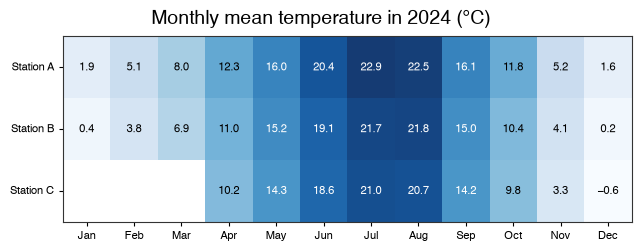

In [19]:
Heatmap(
    # None cells stay blank
    data=monthly_2024,
    title="Monthly mean temperature in 2024 (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_heatmap_values=True,
    valfmt=VALUE_FORMAT.DECIMAL,
).show()

### Axis range

A large table often has one interesting corner. `xmin`, `xmax`, `ymin` and `ymax` crop the view in cell indices, where a cell spans half a unit on either side of its index: `xmin=-0.5` and `xmax=2.5` keep the first three columns whole. The first row is drawn at the top, so the row limits run the other way: `ymin=2.5` and `ymax=-0.5` keep the first three rows in their order. Cropped to the first three months and the three European cities, the chart shows only where winter bites. The colormap still spans the whole table, so the colors stay comparable with the full chart.

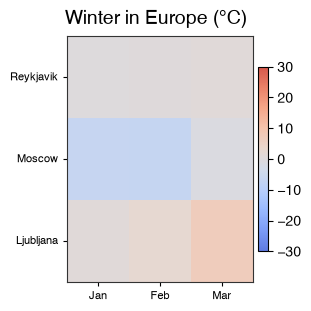

In [20]:
Heatmap(
    data=temperatures,
    style={"plot_heatmap_cmap": COLORS.Coolwarm},
    vmin=-30,
    vmax=30,
    # January to March
    xmin=-0.5,
    xmax=2.5,
    # the first three rows, the first row on top
    ymin=2.5,
    ymax=-0.5,
    title="Winter in Europe (°C)",
    figsize=FIG_SIZE.HALF_SQUARE,
    show_colorbars=True,
).show()

### Date labels

Rows or columns are often dates: months, weeks, years. `x` and `y` can hold real temporal objects (`datetime`, `date`, `numpy.datetime64`, or a pandas `Timestamp`); the cells keep their grid positions, and the dates print through `xticks_format` or `yticks_format`, a [DATE_FORMAT](../../../references/constants/#datachart.constants.DATE_FORMAT) member or any `strftime` pattern. The same `monthly_2024` table, labelled by the first day of each month, prints the months with their year.

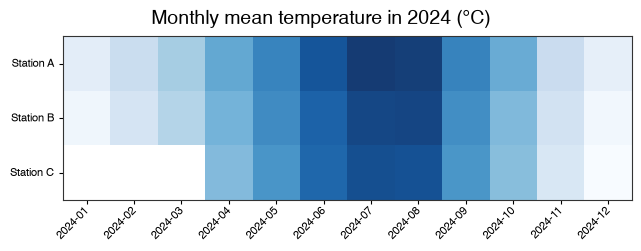

In [21]:
from datetime import date

from datachart.constants import DATE_FORMAT

Heatmap(
    # the first day of each month as the column labels
    data={**monthly_2024, "x": [date(2024, month, 1) for month in range(1, 13)]},
    title="Monthly mean temperature in 2024 (°C)",
    figsize=FIG_SIZE.FULL_SHORT,
    # print the dates as year and month
    xticks_format=DATE_FORMAT.YEAR_MONTH,
    xtickrotate=45,
).show()

## Real-World Examples

The examples below put the features above to work, each one answering a question. The data lives in hidden cells; each example says what its data is and where it comes from.

### Example 1: How Do Penguin Measurements Move Together? (Diverging Colormap, Pinned Range, and a Note)

`correlations` holds the Pearson correlation between four body measurements (bill length, bill depth, flipper length and body mass) of the 342 penguins in the [Palmer penguins](https://allisonhorst.github.io/palmerpenguins/) dataset (CC0). A correlation is signed, so the chart needs a diverging colormap whose white middle sits on zero: `COLORS.RdBu` pinned to the −1 to 1 range with `vmin` and `vmax` gives equally strong correlations of either sign equally dark shades. The variables label both axes, square cells keep the matrix symmetric, and the cells carry the coefficients. One cell is a known trap: bill length and depth correlate negatively across all penguins but positively within each species, a case of Simpson's paradox, and a note says so.

In [22]:
VARIABLES = ["Bill length", "Bill depth", "Flipper length", "Body mass"]

# Pearson correlation between the body measurements of the Palmer penguins
correlations = {"x": VARIABLES, "y": VARIABLES, "z": [
    [1.00, -0.24, 0.66, 0.60],
    [-0.24, 1.00, -0.58, -0.47],
    [0.66, -0.58, 1.00, 0.87],
    [0.60, -0.47, 0.87, 1.00],
]}

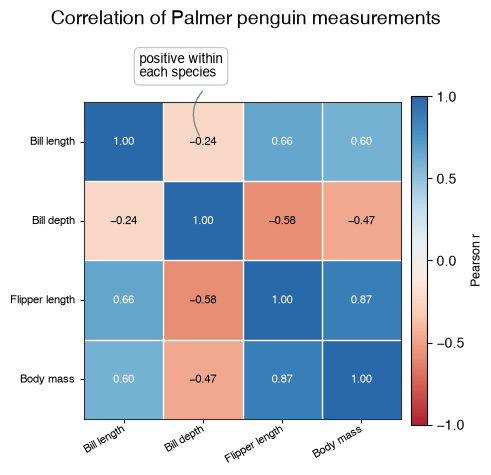

In [23]:
Heatmap(
    data=correlations,
    # a diverging colormap, pinned so that zero sits on white
    style={
        "plot_heatmap_cmap": COLORS.RdBu,
        "plot_heatmap_edge_width": 1,
        "plot_heatmap_edge_color": "#FFFFFF",
    },
    vmin=-1,
    vmax=1,
    # a note on the bill length and depth cell
    texts={
        "text": "positive within\neach species",
        "x": 0.2,
        "y": -0.95,
        "target": (1, 0),
    },
    title="Correlation of Palmer penguin measurements",
    xtickrotate=30,
    figsize=FIG_SIZE.SQUARE,
    aspect_ratio=ASPECT_RATIO.EQUAL,
    show_colorbars=True,
    colorbar={"label": "Pearson r", "ticks": [-1, -0.5, 0, 0.5, 1]},
    show_heatmap_values=True,
    valfmt=VALUE_FORMAT.DECIMAL_2,
).show()

### Example 2: Which Topics Does the Classifier Confuse? (Integer Cells and an Emphasis Grid)

`confusion` holds the illustrative confusion matrix of a topic classifier evaluated on 1,000 news articles, 250 per topic: each row is the true topic, each column the predicted one, and each cell a count of articles. The diagonal holds the correct predictions; the question is where the errors go. An `emphasis` grid highlights the two cells where business and politics articles are mistaken for each other and mutes the rest, so the largest confusion stands out without hiding the other counts. `VALUE_FORMAT.INTEGER` writes the counts, and the colorbar is left out because the cells already carry the numbers.

In [24]:
TOPICS = ["Business", "Politics", "Science", "Sports"]

# rows: true topic, columns: predicted topic, cells: number of articles (illustrative)
CONFUSION = [
    [218, 21, 9, 2],
    [27, 209, 6, 8],
    [14, 5, 226, 5],
    [3, 6, 4, 237],
]
confusion = {"x": TOPICS, "y": TOPICS, "z": CONFUSION}

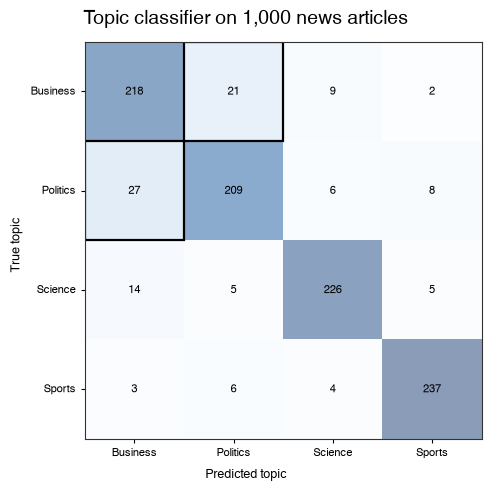

In [25]:
# the business-politics mix-ups, both ways
MIXUPS = {(0, 1), (1, 0)}
roles = [
    ["highlight" if (i, j) in MIXUPS else "background" for j in range(4)]
    for i in range(4)
]

Heatmap(
    data={**confusion, "emphasis": roles},
    style={"plot_heatmap_cmap": COLORS.Blues},
    title="Topic classifier on 1,000 news articles",
    xlabel="Predicted topic",
    ylabel="True topic",
    figsize=FIG_SIZE.SQUARE,
    aspect_ratio=ASPECT_RATIO.EQUAL,
    # write the counts into the cells
    show_heatmap_values=True,
    valfmt=VALUE_FORMAT.INTEGER,
).show()

### Example 3: Did Fine-Tuning Fix the Confusion? (Shared Value Range and a Grid)

`fine_tuned` holds the illustrative confusion matrix of a fine-tuned version of the Example 2 classifier, evaluated on the same 1,000 articles. The question is whether the business and politics mix-ups shrank. The two matrices are drawn as two heatmaps with the same `vmin` and `vmax`, pinned to the 0 to 250 range, so an equally dark cell means an equally large count in either one; without it, each matrix would stretch its own colormap and the shades would not compare. [Grid](../../utility/grid/) sets them side by side and adds a bar chart of each topic's recall (the share of its 250 articles classified correctly) underneath, which states the improvement in one number per topic.

In [26]:
# rows: true topic, columns: predicted topic, for the fine-tuned model (illustrative)
FINE_TUNED = [
    [236, 9, 4, 1],
    [12, 231, 3, 4],
    [6, 2, 239, 3],
    [1, 3, 2, 244],
]
fine_tuned = {"x": TOPICS, "y": TOPICS, "z": FINE_TUNED}
recall = [
    [{"label": topic, "y": matrix[i][i] / 250} for i, topic in enumerate(TOPICS)]
    for matrix in [CONFUSION, FINE_TUNED]
]

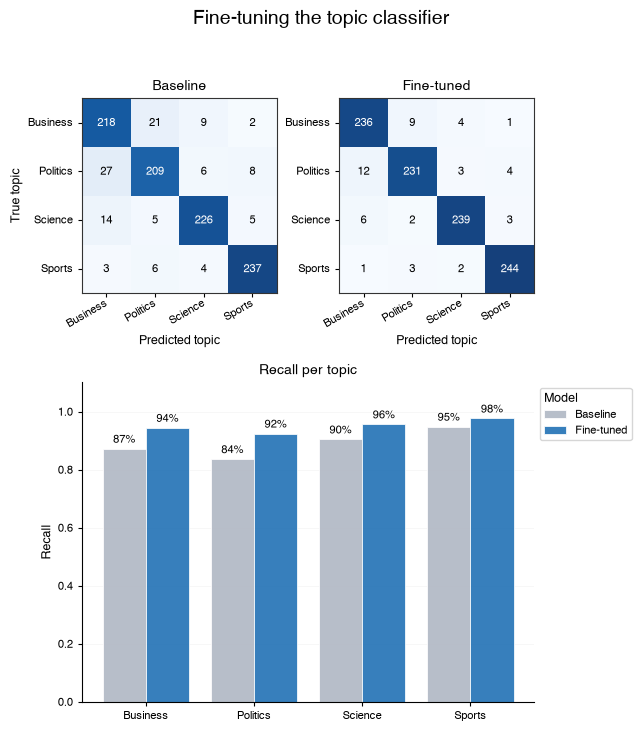

In [27]:
from datachart.charts import BarChart
from datachart.constants import LEGEND_LOCATION, SHOW_GRID
from datachart.utils import Grid


def matrix(data, title, ylabel=None):
    # one value range for every matrix, so the shades compare
    return Heatmap(
        data=data,
        style={"plot_heatmap_cmap": COLORS.Blues},
        vmin=0,
        vmax=250,
        title=title,
        xlabel="Predicted topic",
        ylabel=ylabel,
        xtickrotate=30,
        aspect_ratio=ASPECT_RATIO.EQUAL,
        show_heatmap_values=True,
        valfmt=VALUE_FORMAT.INTEGER,
    )


recalls = BarChart(
    data=recall,
    subtitle=["Baseline", "Fine-tuned"],
    style=[{"plot_bar_color": "#b0b7c3"}, {"plot_bar_color": "#2171b5"}],
    title="Recall per topic",
    ylabel="Recall",
    show_grid=SHOW_GRID.Y,
    show_legend=True,
    legend={"title": "Model", "location": LEGEND_LOCATION.OUTSIDE_RIGHT},
    ymin=0,
    ymax=1.1,
    show_values=True,
    value_format=VALUE_FORMAT.PERCENT_INT,
)

Grid(
    [
        [matrix(confusion, "Baseline", ylabel="True topic"), matrix(fine_tuned, "Fine-tuned")],
        [recalls],
    ],
    title="Fine-tuning the topic classifier",
    figsize=FIG_SIZE.FULL_TALL,
).show()